In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import gzip
import os
from typing import Tuple, List
import time

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


In [3]:
def load_mnist_data() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Загружает данные MNIST с альтернативных источников
    Возвращает: X_train, y_train, X_test, y_test
    """
    urls = {
        'train_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
        'train_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
        'test_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
        'test_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz'
    }

    data_dir = 'mnist_data'
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    def download_and_extract(url: str, filename: str) -> np.ndarray:
        filepath = os.path.join(data_dir, filename)

        if not os.path.exists(filepath):
            print(f"Загружаем {filename}...")
            try:
                urllib.request.urlretrieve(url, filepath)
            except Exception as e:
                print(f"Ошибка при загрузке {filename}: {e}")
                if 'train-images' in filename:
                    alt_url = 'https://github.com/pjreddie/mnist/raw/master/train-images-idx3-ubyte.gz'
                elif 'train-labels' in filename:
                    alt_url = 'https://github.com/pjreddie/mnist/raw/master/train-labels-idx1-ubyte.gz'
                elif 'test-images' in filename:
                    alt_url = 'https://github.com/pjreddie/mnist/raw/master/t10k-images-idx3-ubyte.gz'
                elif 'test-labels' in filename:
                    alt_url = 'https://github.com/pjreddie/mnist/raw/master/t10k-labels-idx1-ubyte.gz'

                print(f"Пробуем альтернативный источник: {alt_url}")
                urllib.request.urlretrieve(alt_url, filepath)

        with gzip.open(filepath, 'rb') as f:
            if 'images' in filename:
                f.read(16)
                data = np.frombuffer(f.read(), dtype=np.uint8)
                return data.reshape(-1, 28 * 28).astype(np.float32) / 255.0
            else:
                f.read(8)
                return np.frombuffer(f.read(), dtype=np.uint8)

    X_train = download_and_extract(urls['train_images'], 'train-images-idx3-ubyte.gz')
    y_train = download_and_extract(urls['train_labels'], 'train-labels-idx1-ubyte.gz')
    X_test = download_and_extract(urls['test_images'], 'test-images-idx3-ubyte.gz')
    y_test = download_and_extract(urls['test_labels'], 'test-labels-idx1-ubyte.gz')

    print(f"Данные загружены:")
    print(f"Обучающая выборка: {X_train.shape[0]} изображений")
    print(f"Тестовая выборка: {X_test.shape[0]} изображений")
    print(f"Размер изображения: {X_train.shape[1]} пикселей")

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_mnist_data()

Загружаем train-images-idx3-ubyte.gz...
Загружаем train-labels-idx1-ubyte.gz...
Загружаем test-images-idx3-ubyte.gz...
Загружаем test-labels-idx1-ubyte.gz...
Данные загружены:
Обучающая выборка: 60000 изображений
Тестовая выборка: 10000 изображений
Размер изображения: 784 пикселей


In [4]:
class ActivationFunctions:
    """Класс с реализацией функций активации и их производных"""

    @staticmethod
    def relu(x: np.ndarray) -> np.ndarray:
        """Функция активации ReLU"""
        return np.maximum(0, x)

    @staticmethod
    def relu_derivative(x: np.ndarray) -> np.ndarray:
        """Производная функции ReLU"""
        return (x > 0).astype(float)

    @staticmethod
    def softmax(x: np.ndarray) -> np.ndarray:
        """Функция активации Softmax"""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    @staticmethod
    def softmax_derivative(x: np.ndarray) -> np.ndarray:
        """Производная функции Softmax"""
        s = ActivationFunctions.softmax(x)
        return s * (1 - s)

print("Тестирование функций активации:")
test_input = np.array([[-2, -1, 0, 1, 2], [3, 4, 5, 6, 7]])

print(f"Входные данные:\n{test_input}")
print(f"ReLU:\n{ActivationFunctions.relu(test_input)}")
print(f"Softmax:\n{ActivationFunctions.softmax(test_input)}")
print(f"Сумма Softmax по строкам: {np.sum(ActivationFunctions.softmax(test_input), axis=1)}")

Тестирование функций активации:
Входные данные:
[[-2 -1  0  1  2]
 [ 3  4  5  6  7]]
ReLU:
[[0 0 0 1 2]
 [3 4 5 6 7]]
Softmax:
[[0.01165623 0.03168492 0.08612854 0.23412166 0.63640865]
 [0.01165623 0.03168492 0.08612854 0.23412166 0.63640865]]
Сумма Softmax по строкам: [1. 1.]


In [5]:
class LossFunctions:
    """Класс с реализацией функций потерь"""

    @staticmethod
    def cross_entropy_loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """
        Функция потерь Cross-entropy

        Args:
            y_pred: Предсказания модели (вероятности)
            y_true: Истинные метки (one-hot encoded)

        Returns:
            Средняя потеря по батчу
        """
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        return loss

    @staticmethod
    def cross_entropy_loss_derivative(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
        """
        Производная функции потерь Cross-entropy

        Args:
            y_pred: Предсказания модели (вероятности)
            y_true: Истинные метки (one-hot encoded)

        Returns:
            Градиент потерь
        """
        return y_pred - y_true

def one_hot_encode(labels: np.ndarray, num_classes: int = 10) -> np.ndarray:
    """
    Преобразует метки в one-hot encoding

    Args:
        labels: Массив меток
        num_classes: Количество классов

    Returns:
        One-hot encoded массив
    """
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1
    return one_hot

print("Тестирование функции потерь:")
test_pred = np.array([[0.1, 0.2, 0.7], [0.8, 0.1, 0.1]])
test_true = np.array([[0, 0, 1], [1, 0, 0]])

loss = LossFunctions.cross_entropy_loss(test_pred, test_true)
gradient = LossFunctions.cross_entropy_loss_derivative(test_pred, test_true)

print(f"Предсказания:\n{test_pred}")
print(f"Истинные метки:\n{test_true}")
print(f"Потеря: {loss:.4f}")
print(f"Градиент:\n{gradient}")

test_labels = np.array([0, 1, 2, 3, 4])
one_hot_labels = one_hot_encode(test_labels)
print(f"\nOne-hot encoding для {test_labels}:")
print(one_hot_labels)

Тестирование функции потерь:
Предсказания:
[[0.1 0.2 0.7]
 [0.8 0.1 0.1]]
Истинные метки:
[[0 0 1]
 [1 0 0]]
Потеря: 0.2899
Градиент:
[[ 0.1  0.2 -0.3]
 [-0.2  0.1  0.1]]

One-hot encoding для [0 1 2 3 4]:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [6]:
class NeuralNetwork:
    """
    Нейронная сеть с двумя слоями:
    - Скрытый слой с ReLU активацией
    - Выходной слой с Softmax активацией
    """

    def __init__(self, input_size: int, hidden_size: int, output_size: int, learning_rate: float = 0.01):
        """
        Инициализация нейронной сети

        Args:
            input_size: Размер входного слоя (784 для MNIST)
            hidden_size: Размер скрытого слоя
            output_size: Размер выходного слоя (10 для MNIST)
            learning_rate: Скорость обучения
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

        self.z1 = None
        self.a1 = None
        self.z2 = None
        self.a2 = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Прямой проход через сеть

        Args:
            X: Входные данные (batch_size, input_size)

        Returns:
            Предсказания сети (batch_size, output_size)
        """
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = ActivationFunctions.relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = ActivationFunctions.softmax(self.z2)

        return self.a2

    def backward(self, X: np.ndarray, y: np.ndarray, y_pred: np.ndarray) -> None:
        """
        Обратный проход (backpropagation)

        Args:
            X: Входные данные
            y: Истинные метки (one-hot encoded)
            y_pred: Предсказания сети
        """
        m = X.shape[0]

        dz2 = LossFunctions.cross_entropy_loss_derivative(y_pred, y)

        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * ActivationFunctions.relu_derivative(self.z1)

        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train_step(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        Один шаг обучения

        Args:
            X: Входные данные
            y: Истинные метки (one-hot encoded)

        Returns:
            Значение функции потерь
        """
        y_pred = self.forward(X)

        loss = LossFunctions.cross_entropy_loss(y_pred, y)

        self.backward(X, y, y_pred)

        return loss

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Предсказание классов

        Args:
            X: Входные данные

        Returns:
            Предсказанные классы
        """
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
        """
        Оценка точности модели

        Args:
            X: Входные данные
            y: Истинные метки (не one-hot)

        Returns:
            Кортеж (loss, accuracy)
        """
        y_pred = self.forward(X)
        y_one_hot = one_hot_encode(y)
        loss = LossFunctions.cross_entropy_loss(y_pred, y_one_hot)

        predictions = np.argmax(y_pred, axis=1)
        accuracy = np.mean(predictions == y)

        return loss, accuracy

nn = NeuralNetwork(input_size=784, hidden_size=128, output_size=10, learning_rate=0.01)
print(f"Нейронная сеть создана:")
print(f"Входной слой: {nn.input_size} нейронов")
print(f"Скрытый слой: {nn.hidden_size} нейронов")
print(f"Выходной слой: {nn.output_size} нейронов")
print(f"Скорость обучения: {nn.learning_rate}")
print(f"Общее количество параметров: {nn.W1.size + nn.b1.size + nn.W2.size + nn.b2.size}")


Нейронная сеть создана:
Входной слой: 784 нейронов
Скрытый слой: 128 нейронов
Выходной слой: 10 нейронов
Скорость обучения: 0.01
Общее количество параметров: 101770


In [7]:
def train_neural_network(nn: NeuralNetwork, X_train: np.ndarray, y_train: np.ndarray,
                         X_test: np.ndarray, y_test: np.ndarray,
                         epochs: int = 20, batch_size: int = 128) -> dict:
    """
    Функция обучения нейронной сети с отслеживанием метрик

    Args:
        nn: Экземпляр нейронной сети
        X_train, y_train: Обучающие данные
        X_test, y_test: Тестовые данные
        epochs: Количество эпох обучения
        batch_size: Размер батча

    Returns:
        Словарь с историей обучения
    """
    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'epoch_times': []
    }

    print(f"Начало обучения:")
    print(f"Количество эпох: {epochs}")
    print(f"Размер батча: {batch_size}")
    print(f"Количество батчей на эпоху: {n_batches}")
    print("-" * 80)

    y_train_one_hot = one_hot_encode(y_train)

    for epoch in range(epochs):
        epoch_start_time = time.time()

        indices = np.random.permutation(n_samples)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train_one_hot[indices]

        epoch_losses = []

        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size

            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]

            loss = nn.train_step(X_batch, y_batch)
            epoch_losses.append(loss)

        avg_train_loss = np.mean(epoch_losses)
        train_loss, train_acc = nn.evaluate(X_train, y_train)
        test_loss, test_acc = nn.evaluate(X_test, y_test)

        epoch_time = time.time() - epoch_start_time

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)

        print(f"Эпоха {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
              f"Time: {epoch_time:.2f}s")

    print("-" * 80)
    print(f"Обучение завершено!")
    print(f"Финальная точность на тесте: {history['test_acc'][-1]:.4f}")
    print(f"Общее время обучения: {sum(history['epoch_times']):.2f}s")

    return history

history = train_neural_network(
    nn, X_train, y_train, X_test, y_test,
    epochs=20,
    batch_size=128
)

Начало обучения:
Количество эпох: 20
Размер батча: 128
Количество батчей на эпоху: 468
--------------------------------------------------------------------------------
Эпоха 1/20 | Train Loss: 0.6695 | Train Acc: 0.8432 | Test Loss: 0.6430 | Test Acc: 0.8517 | Time: 2.60s
Эпоха 2/20 | Train Loss: 0.4776 | Train Acc: 0.8776 | Test Loss: 0.4545 | Test Acc: 0.8861 | Time: 2.46s
Эпоха 3/20 | Train Loss: 0.4085 | Train Acc: 0.8912 | Test Loss: 0.3882 | Test Acc: 0.8972 | Time: 2.50s
Эпоха 4/20 | Train Loss: 0.3707 | Train Acc: 0.8992 | Test Loss: 0.3525 | Test Acc: 0.9044 | Time: 2.90s
Эпоха 5/20 | Train Loss: 0.3455 | Train Acc: 0.9049 | Test Loss: 0.3288 | Test Acc: 0.9103 | Time: 4.26s
Эпоха 6/20 | Train Loss: 0.3270 | Train Acc: 0.9093 | Test Loss: 0.3124 | Test Acc: 0.9144 | Time: 2.52s
Эпоха 7/20 | Train Loss: 0.3121 | Train Acc: 0.9128 | Test Loss: 0.2985 | Test Acc: 0.9184 | Time: 2.47s
Эпоха 8/20 | Train Loss: 0.2998 | Train Acc: 0.9160 | Test Loss: 0.2877 | Test Acc: 0.9203 | Time

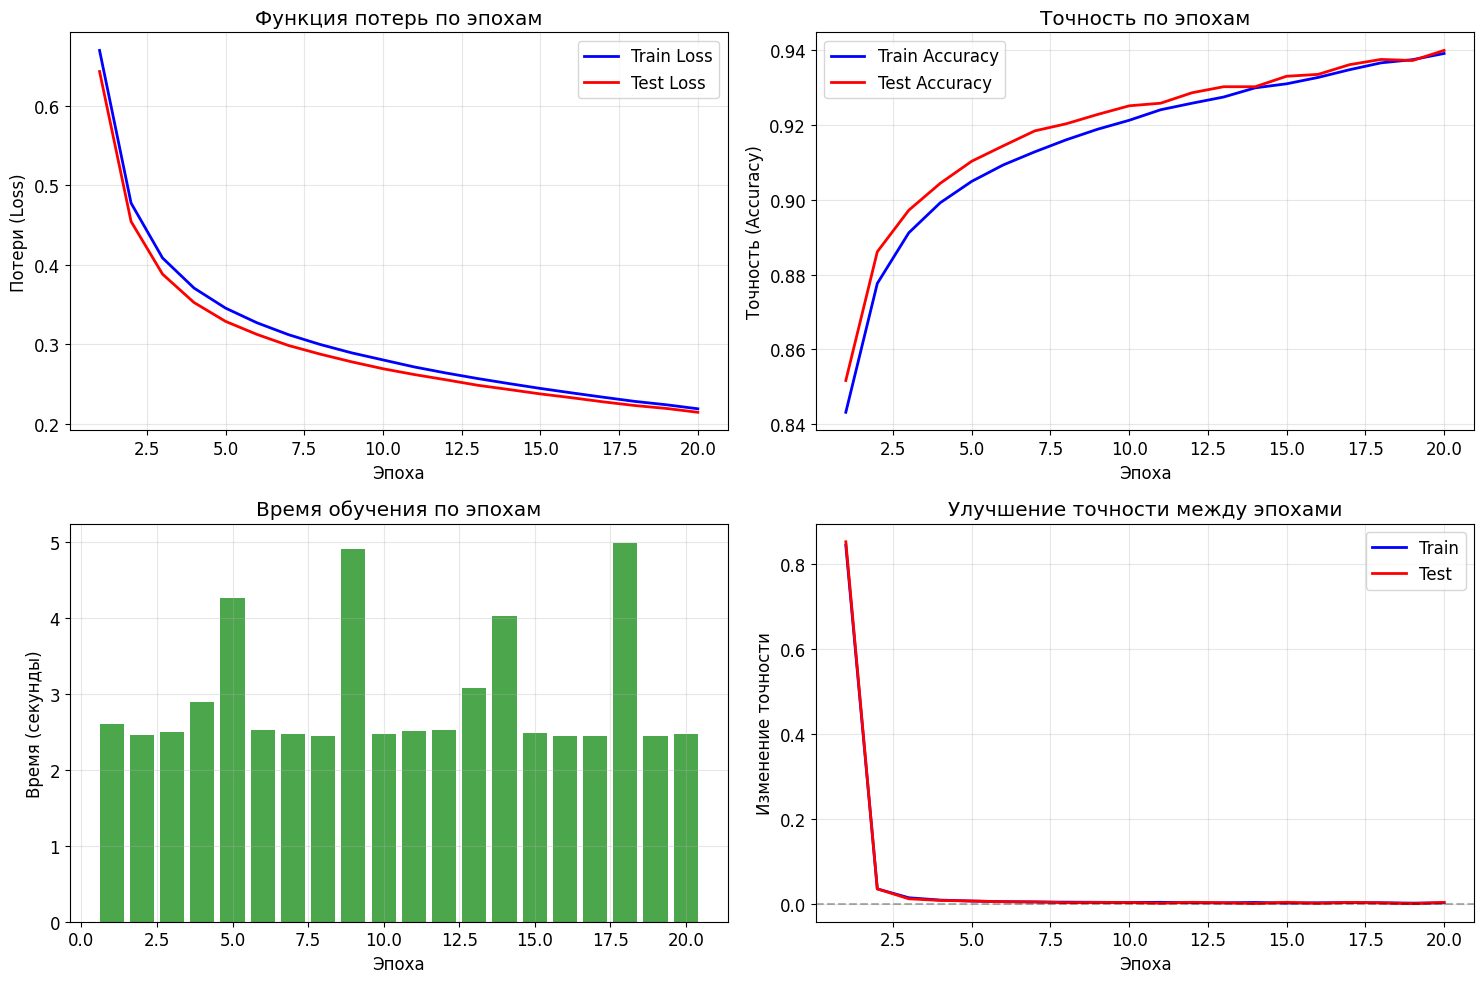


ИТОГОВАЯ СТАТИСТИКА
Начальная точность (train/test): 0.8432 / 0.8517
Финальная точность (train/test): 0.9391 / 0.9399
Улучшение точности: 0.0882
Лучшая точность на тесте: 0.9399 (эпоха 20)
Среднее время на эпоху: 2.95s


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['test_loss'], 'r-', label='Test Loss', linewidth=2)
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Потери (Loss)')
axes[0, 0].set_title('Функция потерь по эпохам')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
axes[0, 1].plot(epochs_range, history['test_acc'], 'r-', label='Test Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Точность (Accuracy)')
axes[0, 1].set_title('Точность по эпохам')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].bar(epochs_range, history['epoch_times'], color='green', alpha=0.7)
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Время (секунды)')
axes[1, 0].set_title('Время обучения по эпохам')
axes[1, 0].grid(True, alpha=0.3)

train_acc_improvement = [history['train_acc'][i] - history['train_acc'][i-1]
                         if i > 0 else history['train_acc'][0]
                         for i in range(len(history['train_acc']))]
test_acc_improvement = [history['test_acc'][i] - history['test_acc'][i-1]
                        if i > 0 else history['test_acc'][0]
                        for i in range(len(history['test_acc']))]

axes[1, 1].plot(epochs_range, train_acc_improvement, 'b-', label='Train', linewidth=2)
axes[1, 1].plot(epochs_range, test_acc_improvement, 'r-', label='Test', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Изменение точности')
axes[1, 1].set_title('Улучшение точности между эпохами')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*80)
print(f"Начальная точность (train/test): {history['train_acc'][0]:.4f} / {history['test_acc'][0]:.4f}")
print(f"Финальная точность (train/test): {history['train_acc'][-1]:.4f} / {history['test_acc'][-1]:.4f}")
print(f"Улучшение точности: {(history['test_acc'][-1] - history['test_acc'][0]):.4f}")
print(f"Лучшая точность на тесте: {max(history['test_acc']):.4f} (эпоха {np.argmax(history['test_acc'])+1})")
print(f"Среднее время на эпоху: {np.mean(history['epoch_times']):.2f}s")
print("="*80)

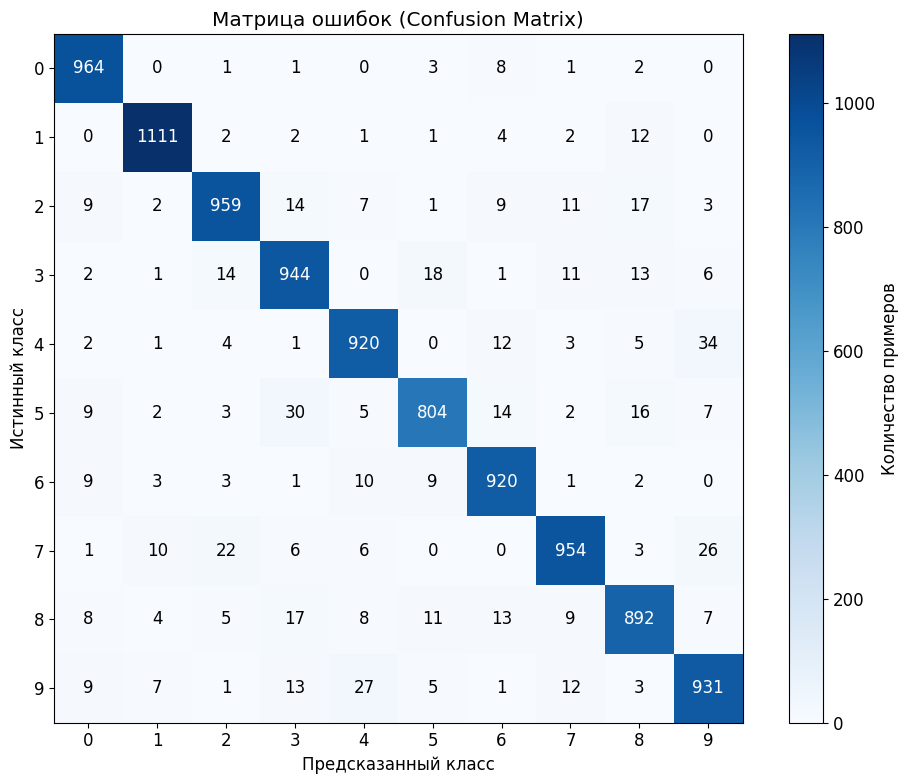


Точность распознавания по классам:
--------------------------------------------------
Цифра 0: 0.9837 (964/980)
Цифра 1: 0.9789 (1111/1135)
Цифра 2: 0.9293 (959/1032)
Цифра 3: 0.9347 (944/1010)
Цифра 4: 0.9369 (920/982)
Цифра 5: 0.9013 (804/892)
Цифра 6: 0.9603 (920/958)
Цифра 7: 0.9280 (954/1028)
Цифра 8: 0.9158 (892/974)
Цифра 9: 0.9227 (931/1009)
--------------------------------------------------
Общая точность: 0.9399


In [9]:
def compute_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int = 10) -> np.ndarray:
    """Вычисление матрицы ошибок"""
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        conf_matrix[true, pred] += 1
    return conf_matrix

y_test_pred = nn.predict(X_test)
conf_matrix = compute_confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Количество примеров')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Confusion Matrix)')

for i in range(10):
    for j in range(10):
        color = 'white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black'
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color=color)

plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

print("\nТочность распознавания по классам:")
print("-" * 50)
for digit in range(10):
    correct = conf_matrix[digit, digit]
    total = np.sum(conf_matrix[digit, :])
    accuracy = correct / total if total > 0 else 0
    print(f"Цифра {digit}: {accuracy:.4f} ({correct}/{total})")

overall_accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)
print("-" * 50)
print(f"Общая точность: {overall_accuracy:.4f}")

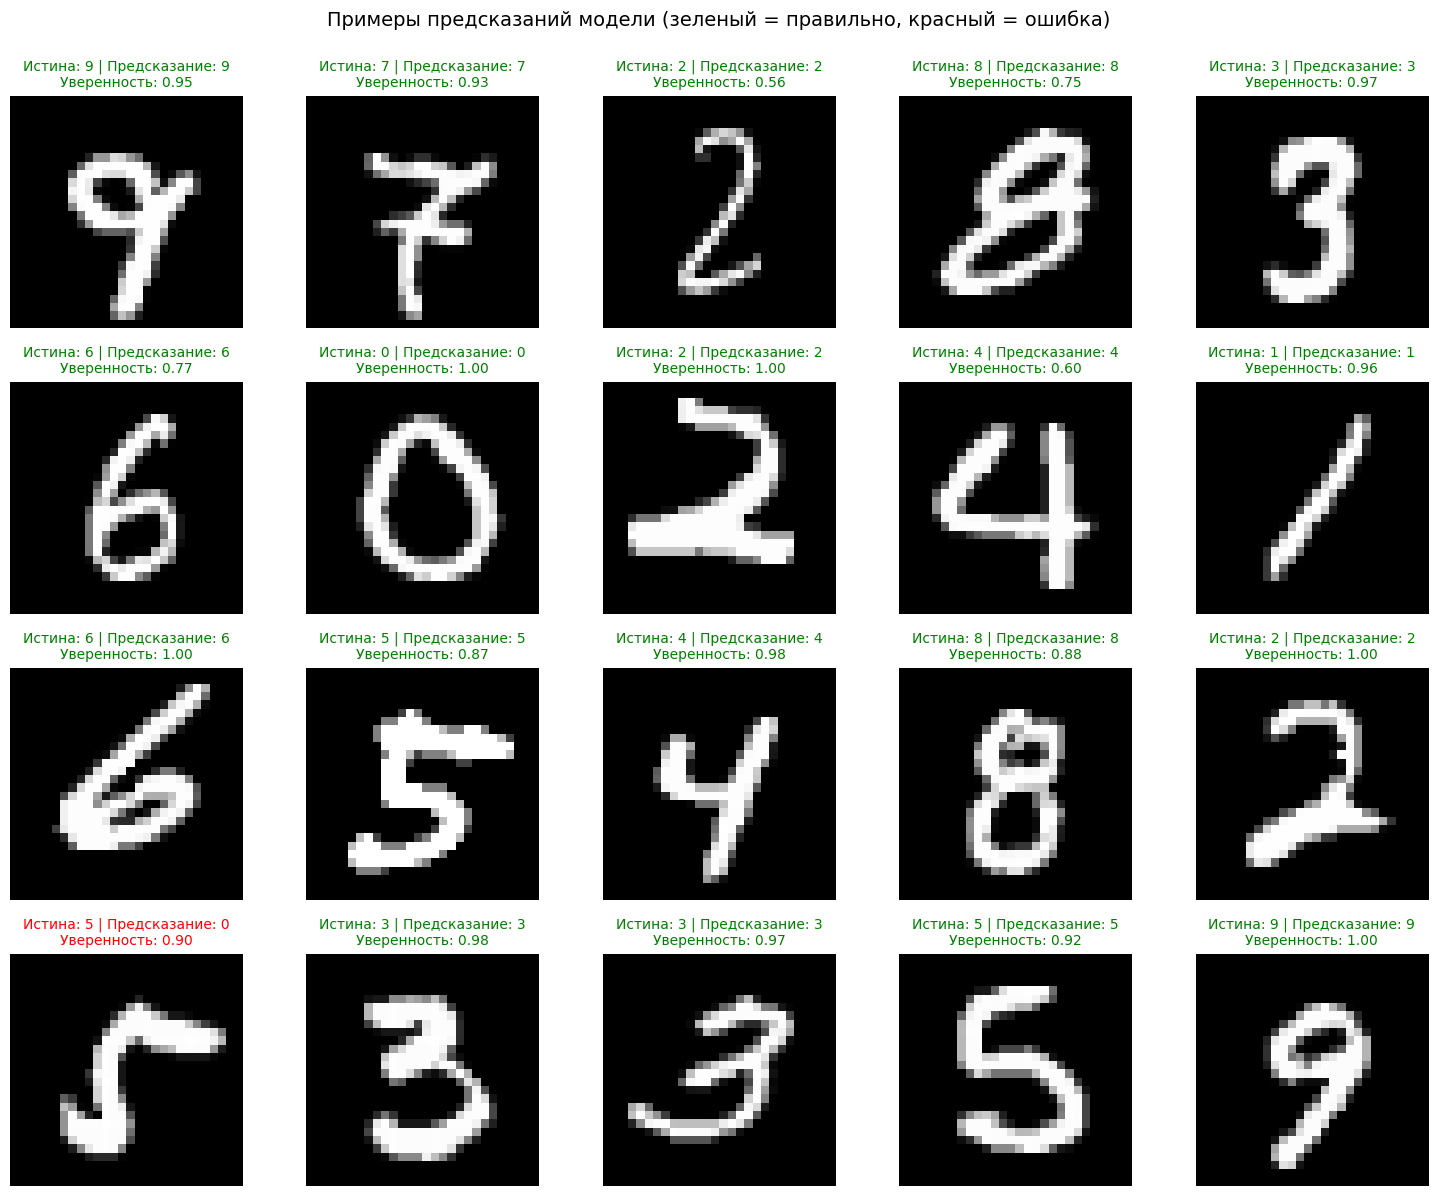

In [10]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

random_indices = np.random.choice(len(X_test), 20, replace=False)

for idx, ax_idx in enumerate(random_indices):
    row = idx // 5
    col = idx % 5

    image = X_test[ax_idx].reshape(28, 28)
    true_label = y_test[ax_idx]
    pred_label = y_test_pred[ax_idx]

    probs = nn.forward(X_test[ax_idx:ax_idx+1])[0]
    confidence = probs[pred_label]

    axes[row, col].imshow(image, cmap='gray')

    color = 'green' if true_label == pred_label else 'red'
    axes[row, col].set_title(f'Истина: {true_label} | Предсказание: {pred_label}\n'
                             f'Уверенность: {confidence:.2f}',
                             color=color, fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('Примеры предсказаний модели (зеленый = правильно, красный = ошибка)',
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

Всего ошибок: 601 из 10000 (6.01%)


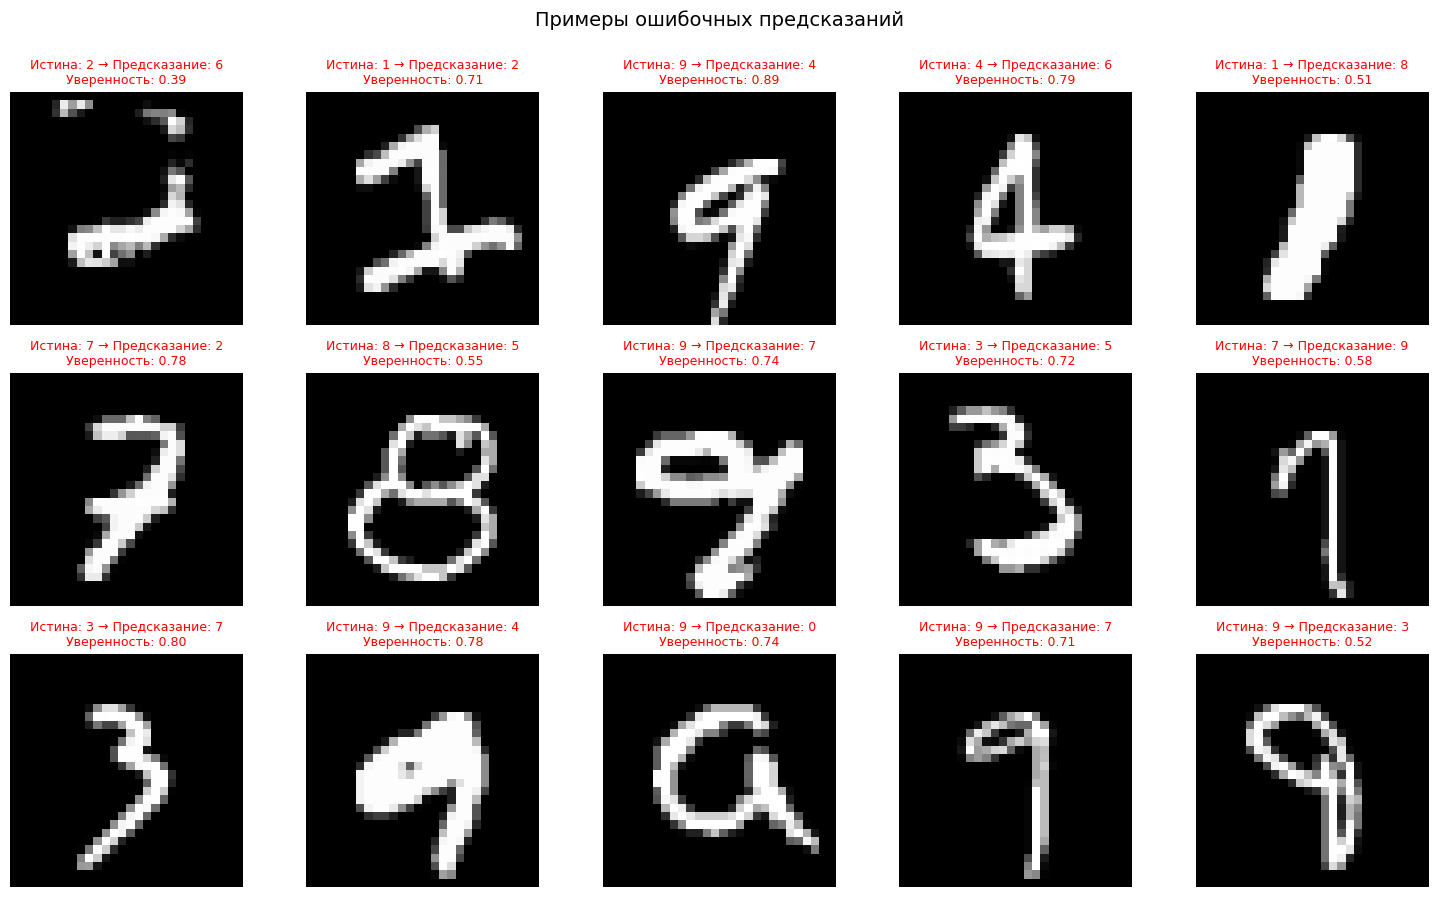

In [11]:
errors_indices = np.where(y_test != y_test_pred)[0]
print(f"Всего ошибок: {len(errors_indices)} из {len(y_test)} ({len(errors_indices)/len(y_test)*100:.2f}%)")

if len(errors_indices) > 0:
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))

    error_samples = np.random.choice(errors_indices, min(15, len(errors_indices)), replace=False)

    for idx, error_idx in enumerate(error_samples):
        row = idx // 5
        col = idx % 5

        image = X_test[error_idx].reshape(28, 28)
        true_label = y_test[error_idx]
        pred_label = y_test_pred[error_idx]

        probs = nn.forward(X_test[error_idx:error_idx+1])[0]
        confidence = probs[pred_label]

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'Истина: {true_label} → Предсказание: {pred_label}\n'
                                 f'Уверенность: {confidence:.2f}',
                                 color='red', fontsize=9)
        axes[row, col].axis('off')

    plt.suptitle('Примеры ошибочных предсказаний', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("Модель не совершила ошибок на тестовой выборке!")